In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text

In [2]:
data=pd.read_csv(r"marketing.csv")
data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
0,13829,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,-1,0,unknown,no
1,22677,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,-1,0,unknown,no
2,10541,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,-1,0,unknown,no
3,13689,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,-1,0,unknown,no
4,11304,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,14023,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,87,5,failure,yes
12866,17259,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,93,2,failure,yes
12867,15200,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,172,2,failure,no
12868,13775,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,-1,0,unknown,no


In [3]:
data.describe(include="all")

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
count,12870.000000,12870.000000,12870,12870,12870,12870,12870.000000,12870,12870,12870,12870.000000,12870,12870.000000,12870.000000,12870.000000,12870,12870
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2858,7490,6368,12662,NaN,6605,11060,8756,NaN,3594,NaN,NaN,NaN,10070,8903
mean,16434.500000,41.091142,NaN,NaN,NaN,NaN,1483.774437,NaN,NaN,NaN,15.641103,NaN,2.659130,45.555478,0.688967,NaN,NaN
std,3715.393317,11.305560,NaN,NaN,NaN,NaN,3311.055181,NaN,NaN,NaN,8.368983,NaN,2.863507,104.449411,2.049696,NaN,NaN
min,10000.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
25%,13217.250000,32.000000,NaN,NaN,NaN,NaN,102.000000,NaN,NaN,NaN,8.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
50%,16434.500000,39.000000,NaN,NaN,NaN,NaN,515.000000,NaN,NaN,NaN,16.000000,NaN,2.000000,-1.000000,0.000000,NaN,NaN
75%,19651.750000,49.000000,NaN,NaN,NaN,NaN,1591.750000,NaN,NaN,NaN,21.000000,NaN,3.000000,-1.000000,0.000000,NaN,NaN


In [4]:
data.isnull().sum()

ID           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
response     0
result       0
dtype: int64

In [5]:
data = data.drop(['ID', 'pdays', 'previous'], axis=1)
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,no
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,no
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,no
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,no
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,no


In [6]:
a={
    "yes":0,
    "no":1
}
data["result"]=data["result"].map(a)
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result
0,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,unknown,1
1,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,unknown,1
2,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,unknown,1
3,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,unknown,1
4,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,failure,0
12866,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,failure,0
12867,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,failure,1
12868,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,unknown,1


In [7]:
for i in data.columns:
    if data[i].dtypes==object:
        print(i)

job
marital
education
default
housing
loan
contact
month
response


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

cols=['job', 'marital', 'education', 'default', 'housing', 
            'loan', 'contact', 'month', 'response']

for i in cols:
    data[i]=le.fit_transform(data[i])
    
data 

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,response,result
0,29,9,2,2,0,18254,0,0,0,11,8,2,3,1
1,26,7,2,1,0,512,1,1,2,5,6,3,3,1
2,30,4,2,1,0,135,0,0,0,14,1,2,3,1
3,41,9,1,3,0,30,1,0,0,10,5,1,3,1
4,27,0,2,1,0,321,0,1,2,2,11,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,47,9,1,1,0,1167,1,0,0,30,0,1,0,0
12866,31,11,1,1,0,111,0,0,0,21,9,2,0,0
12867,37,10,2,2,0,1316,1,0,0,18,9,1,0,1
12868,42,4,1,2,0,479,1,0,2,28,8,2,3,1


In [9]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'response', 'result'],
      dtype='object')

In [10]:
X = data.drop('result', axis=1)
y = data['result']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    return results

In [13]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
one_tree = rfc.estimators_[10]

tree_rules_rf = export_text(one_tree, feature_names=list(X_train.columns))
print(tree_rules_rf)

|--- housing <= 0.50
|   |--- loan <= 0.50
|   |   |--- contact <= 1.50
|   |   |   |--- campaign <= 1.50
|   |   |   |   |--- response <= 2.50
|   |   |   |   |   |--- age <= 25.50
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- age >  25.50
|   |   |   |   |   |   |--- response <= 1.50
|   |   |   |   |   |   |   |--- month <= 9.50
|   |   |   |   |   |   |   |   |--- month <= 7.50
|   |   |   |   |   |   |   |   |   |--- contact <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- education <= 2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 14
|   |   |   |   |   |   |   |   |   |   |--- education >  2.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- contact >  0.50
|   |   |   |   |   |   |   |   |   |   |--- age <= 80.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |   |--- age >  80.50
|   |   

In [15]:
result = evaluate(rfc, X_train, y_train, X_test, y_test)
result

,Dataset,Gini,Precision,Recall
0,Train,100.000000,1.000000,1.00000
1,Test,54.391707,0.809783,0.90303


In [16]:
def plot_feature_importances(model, feature_names):
    
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)
   
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.title("Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis() 
    plt.show()
    
    return importance_df


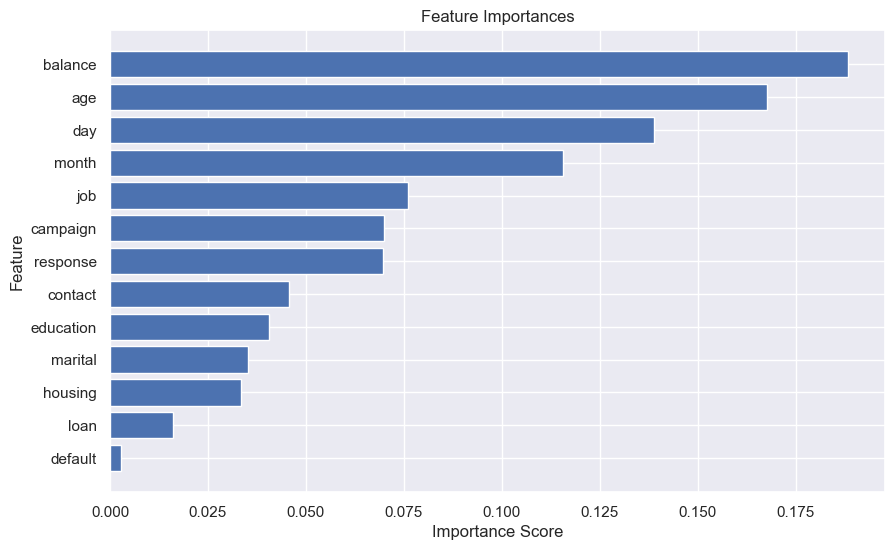

,Feature,Importance
5,balance,0.188416
0,age,0.167743
9,day,0.138773
10,month,0.115661
1,job,0.075968
11,campaign,0.069924
12,response,0.069597
8,contact,0.045616
3,education,0.040614
2,marital,0.035117


In [17]:
feature_names = X_train.columns

feature_importance_df = plot_feature_importances(rfc, feature_names)

feature_importance_df

In [18]:
X_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'response'],
      dtype='object')

In [19]:
clfRF_selected = RandomForestClassifier(random_state=42)
clfRF_selected.fit(X_train[['balance','age','day','month','job','campaign','response']],y_train)

RandomForestClassifier(random_state=42)

In [20]:
result = evaluate(clfRF_selected, X_train[['balance','age','day','month','job','campaign','response']],y_train,
                  X_test[['balance','age','day','month','job','campaign','response']], y_test)
result

,Dataset,Gini,Precision,Recall
0,Train,100.000000,1.000000,1.000000
1,Test,48.707702,0.801855,0.905234


In [21]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start = 200, stop = 1000, num = 10)]
max_depth = [int(x) for x in np.linspace(10, 100, num = 11)]

random_grid = {'n_estimators': n_estimators, 
               'max_features': ['sqrt', 0.3, 0.5, None],
               'max_depth': max_depth, 
               'min_samples_split': [20,50], 
               'min_samples_leaf': [5, 8, 10]} 
print(random_grid)

{'n_estimators': [200, 288, 377, 466, 555, 644, 733, 822, 911, 1000], 'max_features': ['sqrt', 0.3, 0.5, None], 'max_depth': [10, 19, 28, 37, 46, 55, 64, 73, 82, 91, 100], 'min_samples_split': [20, 50], 'min_samples_leaf': [5, 8, 10]}


In [22]:
rf_random = RandomizedSearchCV(
                    estimator=rfc, 
                    param_distributions=random_grid, 
                    n_iter=50,  
                    cv=3, 
                    verbose=1, 
                    random_state=42, 
                    n_jobs=-1)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [10, 19, 28, 37, 46, 55,
                                                      64, 73, 82, 91, 100],
                                        'max_features': ['sqrt', 0.3, 0.5,
                                                         None],
                                        'min_samples_leaf': [5, 8, 10],
                                        'min_samples_split': [20, 50],
                                        'n_estimators': [200, 288, 377, 466,
                                                         555, 644, 733, 822,
                                                         911, 1000]},
                   random_state=42, verbose=1)

In [23]:
rf_random.best_params_

{'n_estimators': 644,
 'min_samples_split': 50,
 'min_samples_leaf': 10,
 'max_features': 0.5,
 'max_depth': 55}

In [24]:
optimized_model = rf_random.best_estimator_


evaluate(optimized_model, X_train, y_train, X_test, y_test)


,Dataset,Gini,Precision,Recall
0,Train,75.260187,0.806684,0.933126
1,Test,55.536827,0.808252,0.917355


In [25]:
test_data=pd.read_excel(r"marketing_test.xlsx")
test_data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response
0,812,25,blue-collar,single,secondary,no,764,yes,no,cellular,18,may,1,-1,0,unknown
1,71,40,blue-collar,single,primary,no,118,no,no,unknown,23,feb,1,-1,0,unknown
2,912,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,1,-1,0,unknown
3,43,30,services,single,secondary,no,495,yes,no,cellular,21,nov,1,-1,0,unknown
4,431,36,blue-collar,married,primary,no,1548,yes,yes,cellular,18,may,2,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,blue-collar,married,secondary,no,413,yes,no,cellular,12,aug,2,182,4,success
853,409,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown
854,105,54,admin.,married,primary,no,976,yes,no,unknown,3,jun,3,-1,0,unknown
855,810,30,unemployed,single,tertiary,no,1159,no,no,telephone,5,jun,1,-1,0,unknown


In [26]:
test_data_final = test_data.drop(['ID', 'pdays', 'previous'], axis=1)

In [27]:
for col in test_data_final.select_dtypes(include=['object']).columns:
    test_data_final[col] = le.fit_transform(test_data_final[col].astype(str))

In [28]:
X_deploy = test_data_final[X_train.columns]

In [30]:
probabilities = optimized_model.predict_proba(X_deploy)[:, 1]
test_data['Probability_of_Interest'] = probabilities
test_data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,Probability_of_Interest
0,812,25,blue-collar,single,secondary,no,764,yes,no,cellular,18,may,1,-1,0,unknown,0.548401
1,71,40,blue-collar,single,primary,no,118,no,no,unknown,23,feb,1,-1,0,unknown,0.746188
2,912,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,1,-1,0,unknown,0.590668
3,43,30,services,single,secondary,no,495,yes,no,cellular,21,nov,1,-1,0,unknown,0.612703
4,431,36,blue-collar,married,primary,no,1548,yes,yes,cellular,18,may,2,-1,0,unknown,0.796010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,blue-collar,married,secondary,no,413,yes,no,cellular,12,aug,2,182,4,success,0.222988
853,409,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown,0.723256
854,105,54,admin.,married,primary,no,976,yes,no,unknown,3,jun,3,-1,0,unknown,0.927539
855,810,30,unemployed,single,tertiary,no,1159,no,no,telephone,5,jun,1,-1,0,unknown,0.358444
